               THÔNG TIN DATASET GỐC
  Tổng số ảnh         : 112,120
  Số bệnh nhân unique : 30,805
  Giới tính           : {'M': 63340, 'F': 48780}
  Tuổi trung bình     : 46.9
       DANH SÁCH NHÃN TỰ ĐỘNG TRÍCH XUẤT TỪ CSV
  Tổng số nhãn tìm được: 15

    0. No Finding                ← bình thường
    1. Atelectasis               
    2. Cardiomegaly              
    3. Consolidation             
    4. Edema                     
    5. Effusion                  
    6. Emphysema                 
    7. Fibrosis                  
    8. Hernia                    
    9. Infiltration              
   10. Mass                      
   11. Nodule                    
   12. Pleural_Thickening        
   13. Pneumonia                 
   14. Pneumothorax              
              THỐNG KÊ CHI TIẾT TỪNG NHÃN

  ───────────────────────────────────────────────────────────────────────────────────
  No Finding (bình thường)              :   60,361 ảnh
  Tổng đơn nhãn có bệnh               

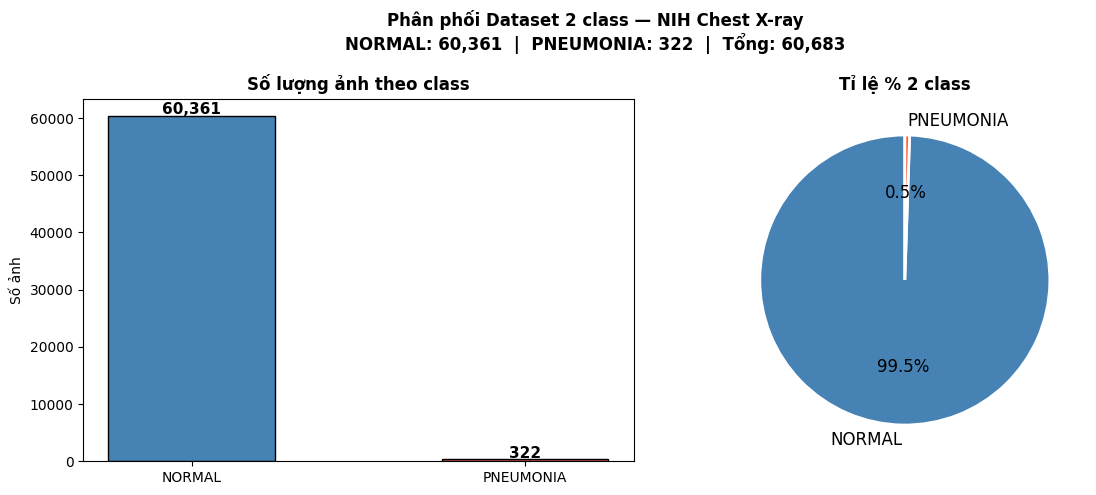


  Đã lưu  → /kaggle/working/filtered_dataset_2class.csv
  Kích thước : 9904.6 KB
  Số dòng    : 60,683
  Các cột    : ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11', 'label', 'image_path']

  Mẫu dữ liệu (5 dòng đầu):
     Image Index Finding Labels  label                                                                                   image_path
00000002_000.png     No Finding NORMAL /kaggle/input/datasets/organizations/nih-chest-xrays/data/images_001/images/00000002_000.png
00000005_000.png     No Finding NORMAL /kaggle/input/datasets/organizations/nih-chest-xrays/data/images_001/images/00000005_000.png
00000005_001.png     No Finding NORMAL /kaggle/input/datasets/organizations/nih-chest-xrays/data/images_001/images/00000005_001.png
00000005_002.png     No Finding NORMAL /kaggle/input/datasets/organizations/nih-chest-xrays/data/image

In [1]:
# ============================================================
# data_filtering.py  
# ============================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

CSV_PATH    = '/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv'
IMAGES_ROOT = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"

TARGET_LABELS = {
    "No Finding": "NORMAL",
    "Pneumonia":  "PNEUMONIA",
}


def load_csv(csv_path: str = CSV_PATH) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    print("               THÔNG TIN DATASET GỐC")
    print("=" * 65)
    print(f"  Tổng số ảnh         : {len(df):,}")
    print(f"  Số bệnh nhân unique : {df['Patient ID'].nunique():,}")
    print(f"  Giới tính           : {df['Patient Gender'].value_counts().to_dict()}")
    print(f"  Tuổi trung bình     : {df['Patient Age'].mean():.1f}")
    print("=" * 65)
    return df


def extract_disease_labels(df: pd.DataFrame) -> list:

    all_labels = set()
    for labels in df["Finding Labels"]:
        for label in labels.split("|"):
            all_labels.add(label.strip())

    sorted_labels  = sorted(all_labels - {"No Finding"})
    disease_labels = ["No Finding"] + sorted_labels


    print("       DANH SÁCH NHÃN TỰ ĐỘNG TRÍCH XUẤT TỪ CSV")
    print("=" * 65)
    print(f"  Tổng số nhãn tìm được: {len(disease_labels)}\n")
    for i, label in enumerate(disease_labels):
        tag = "← bình thường" if label == "No Finding" else ""
        print(f"  {i:>3}. {label:<25} {tag}")
    print("=" * 65)

    return disease_labels


def analyze_and_filter(df: pd.DataFrame, disease_labels: list):

    total = len(df)


    print("              THỐNG KÊ CHI TIẾT TỪNG NHÃN")
    print("=" * 85)
   
    stats = []
    for i, label in enumerate(disease_labels):
        if label == "No Finding":
            single = (df["Finding Labels"] == "No Finding").sum()
            multi  = 0
        else:
            single = (df["Finding Labels"] == label).sum()
            multi  = (
                df["Finding Labels"].str.contains(label, regex=False) &
                df["Finding Labels"].str.contains("|", regex=False)
            ).sum()

        total_label = single + multi
        pct         = (single / total_label * 100) if total_label > 0 else 0

        stats.append({"label": label, "single": single, "multi": multi,
                       "total": total_label, "pct": pct})

        

    df_stats       = pd.DataFrame(stats)
    no_finding_cnt = df_stats[df_stats["label"] == "No Finding"]["single"].values[0]
    total_single   = df_stats[df_stats["label"] != "No Finding"]["single"].sum()
    total_multi    = df_stats["multi"].sum()

    print(f"\n  {'─'*83}")
    print(f"  {'No Finding (bình thường)':<38}: {no_finding_cnt:>8,} ảnh")
    print(f"  {'Tổng đơn nhãn có bệnh':<38}: {total_single:>8,} ảnh")
    print(f"  {'Tổng đa nhãn':<38}: {total_multi:>8,} ảnh  ←  LOẠI BỎ")
    print(f"  {'Tổng dataset gốc':<38}: {total:>8,} ảnh")
    print("=" * 85)


def filter_two_class(df: pd.DataFrame) -> pd.DataFrame:
 
    print("\n" + "=" * 65)
    print("       LỌC 2 CLASS: NORMAL / PNEUMONIA")
    print("=" * 65)

    masks = []
    for orig_label, new_label in TARGET_LABELS.items():
        if orig_label == "No Finding":
            mask = df["Finding Labels"] == "No Finding"
        else:
            mask = (
                df["Finding Labels"].str.contains(orig_label, regex=False) &
                ~df["Finding Labels"].str.contains("|", regex=False)
            )
        count = mask.sum()
        masks.append(mask)
        print(f"  {orig_label:<20} → {new_label:<12}: {count:>7,} ảnh")

    multi_pneumonia = (
        df["Finding Labels"].str.contains("Pneumonia", regex=False) &
        df["Finding Labels"].str.contains("|", regex=False)
    )
    print(f"\n  {'Đa nhãn chứa Pneumonia (loại bỏ)':<40}: {multi_pneumonia.sum():>7,} ảnh")

    combined_mask = masks[0]
    for m in masks[1:]:
        combined_mask = combined_mask | m

    df_filtered = df[combined_mask].copy()

    def assign_label(finding):
        for orig, new in TARGET_LABELS.items():
            if orig == "No Finding" and finding == "No Finding":
                return new
            elif orig != "No Finding" and orig in finding and "|" not in finding:
                return new
        return None

    df_filtered["label"] = df_filtered["Finding Labels"].apply(assign_label)
    df_filtered = df_filtered.dropna(subset=["label"]).reset_index(drop=True)

    print(f"  {'Tổng giữ lại':<40}: {len(df_filtered):>7,} ảnh")
    print("=" * 65)

    return df_filtered


def attach_image_paths(df: pd.DataFrame, images_root: str = IMAGES_ROOT) -> pd.DataFrame:

    print("             QUÉT VÀ GẮN ĐƯỜNG DẪN ẢNH")
    print("=" * 65)
    print(f"\n  Thư mục gốc : {images_root}")

    path_map     = {}
    folder_stats = {}

    for root, dirs, files in os.walk(images_root):
        img_files = [f for f in files if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        if img_files:
            folder_name = os.path.relpath(root, images_root)
            folder_stats[folder_name] = len(img_files)
            for fname in img_files:
                if fname not in path_map:
                    path_map[fname] = os.path.join(root, fname)

    print(f"  {'THƯ MỤC':<50} {'SỐ ẢNH':>8}")
    print(f"  {'-'*50} {'-'*8}")
    for folder, count in sorted(folder_stats.items()):
        print(f"  {folder:<50} {count:>8,}")
    print(f"  {'-'*50} {'-'*8}")
    print(f"  {'TỔNG CỘNG':<50} {sum(folder_stats.values()):>8,}")

    df = df.copy()
    df["image_path"] = df["Image Index"].map(path_map)

    found   = df["image_path"].notna().sum()
    missing = df["image_path"].isna().sum()

    print(f"\n  Tổng ảnh cần tìm  : {len(df):,}")
    print(f"  Tìm thấy          : {found:,}  ({found/len(df)*100:.1f}%)")
    print(f"  Không tìm thấy    : {missing:,}")

    if missing > 0:
        print(f"   Tự động loại bỏ {missing:,} ảnh không tìm thấy")
        df = df.dropna(subset=["image_path"]).reset_index(drop=True)

    print(f"  Còn lại           : {len(df):,} ảnh hợp lệ")
    print("=" * 65)
    return df


def print_statistics(df: pd.DataFrame):
    counts = df["label"].value_counts()
    total  = len(df)

    colors = ["steelblue", "tomato"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax1 = axes[0]
    bars = ax1.bar(counts.index, counts.values, color=colors[:len(counts)],
                   edgecolor="black", width=0.5)
    ax1.set_title("Số lượng ảnh theo class", fontweight="bold")
    ax1.set_ylabel("Số ảnh")
    for bar, val in zip(bars, counts.values):
        ax1.text(bar.get_x() + bar.get_width() / 2, val + total * 0.005,
                 f"{val:,}", ha="center", fontsize=11, fontweight="bold")

    ax2 = axes[1]
    ax2.pie(counts.values, labels=counts.index, colors=colors[:len(counts)],
            autopct="%1.1f%%", startangle=90,
            textprops={"fontsize": 12},
            wedgeprops={"edgecolor": "white", "linewidth": 2})
    ax2.set_title("Tỉ lệ % 2 class", fontweight="bold")

    plt.suptitle(
        f"Phân phối Dataset 2 class — NIH Chest X-ray\n"
        f"NORMAL: {counts.get('NORMAL', 0):,}  |  PNEUMONIA: {counts.get('PNEUMONIA', 0):,}  |  Tổng: {total:,}",
        fontsize=12, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig("/kaggle/working/disease_distribution_2class.png", dpi=120, bbox_inches="tight")
    plt.show()
    


def save_filtered_csv(df: pd.DataFrame,
                      out_path: str = "/kaggle/working/filtered_dataset_2class.csv"):
    if df.empty:
        print("   DataFrame rỗng, không lưu.")
        return
    df.to_csv(out_path, index=False)
    file_size = os.path.getsize(out_path) / 1024
    print(f"\n  Đã lưu  → {out_path}")
    print(f"  Kích thước : {file_size:.1f} KB")
    print(f"  Số dòng    : {len(df):,}")
    print(f"  Các cột    : {df.columns.tolist()}")
    print(f"\n  Mẫu dữ liệu (5 dòng đầu):")
    print(df[["Image Index", "Finding Labels", "label", "image_path"]].head(5).to_string(index=False))


def run_filtering() -> tuple:
    df_raw         = load_csv()
    disease_labels = extract_disease_labels(df_raw)
    analyze_and_filter(df_raw, disease_labels)

    df_filtered = filter_two_class(df_raw)
    df_filtered = attach_image_paths(df_filtered)
    print_statistics(df_filtered)
    save_filtered_csv(df_filtered)

    counts = df_filtered["label"].value_counts()
    print("\n" + "=" * 65)
    print("   HOÀN TẤT!")
    print(f"  → Tìm được {len(disease_labels)} nhãn từ CSV (đã thống kê ở trên)")
    print(f"  → NORMAL    : {counts.get('NORMAL', 0):,} ảnh")
    print(f"  → PNEUMONIA : {counts.get('PNEUMONIA', 0):,} ảnh")
    print(f"  → Tổng giữ lại: {len(df_filtered):,} ảnh")
    print("=" * 65)

    return df_filtered, list(TARGET_LABELS.values())


if __name__ == "__main__":
    df_clean, labels = run_filtering()

  Đã load: 60,683 ảnh

-----------------------------------------------------------------
       MINH HỌA TRƯỚC / SAU PREPROCESSING


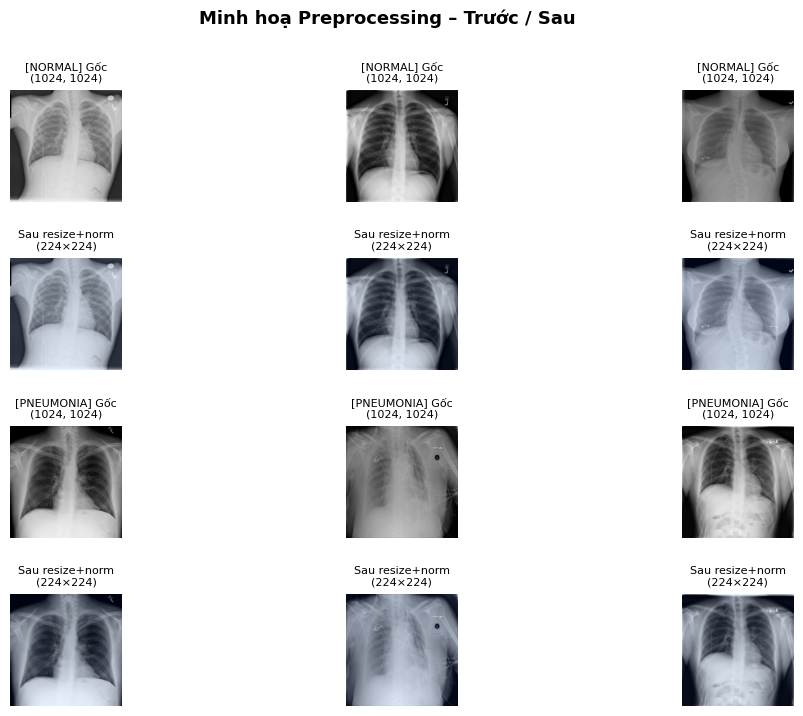

       CHIA TRAIN / VAL / TEST
  TRAIN : 42,478 ảnh  | NORMAL=42,253  PNEUMONIA=  225
  VAL   :  9,102 ảnh  | NORMAL=9,054  PNEUMONIA=   48
  TEST  :  9,103 ảnh  | NORMAL=9,054  PNEUMONIA=   49

  Tỉ lệ  : Train=70%  Val=15%  Test=15%
       MINH HỌA AUGMENTATION


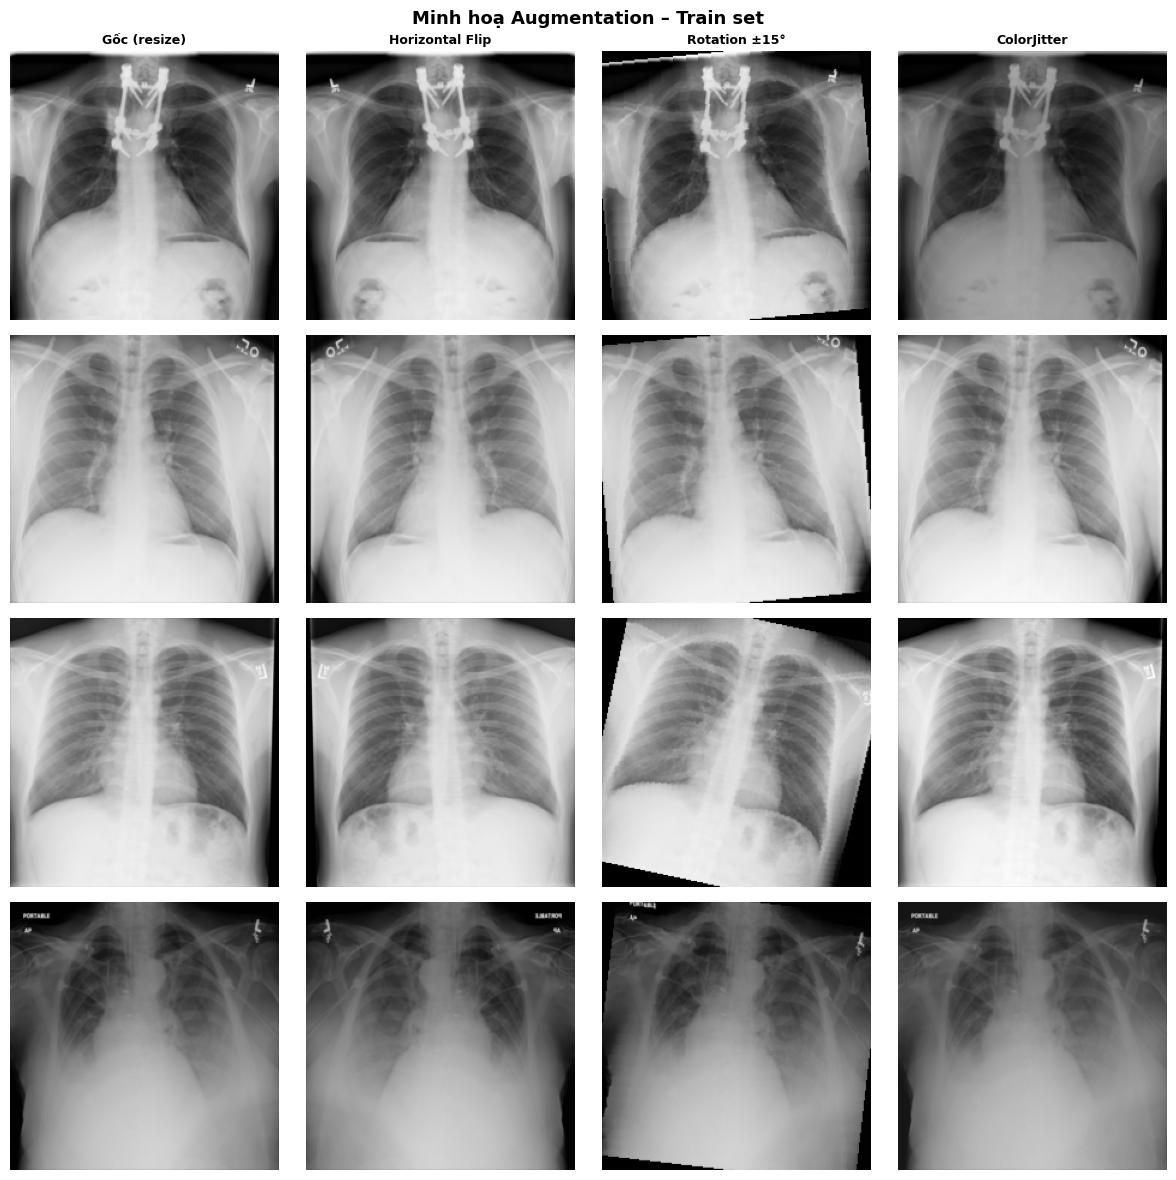

   PREPROCESSING HOÀN TẤT!
  → split_train.csv / split_val.csv / split_test.csv


In [2]:
# ============================================================
# data_preprocessing.py
# ============================================================
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

from sklearn.model_selection import train_test_split

IMG_SIZE   = 224          
MEAN       = [0.485, 0.456, 0.406]  
STD        = [0.229, 0.224, 0.225] 

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
RANDOM_SEED = 42

FILTERED_CSV = "/kaggle/working/filtered_dataset_2class.csv"
OUTPUT_DIR   = "/kaggle/working"


def show_preprocessing_samples(df: pd.DataFrame, n_per_class: int = 3):

    print( "-" * 65)
    print("       MINH HỌA TRƯỚC / SAU PREPROCESSING")
    print("=" * 65)

    labels    = ["NORMAL", "PNEUMONIA"]
    n_classes = len(labels)
    fig       = plt.figure(figsize=(n_per_class * 4, n_classes * 4))
    gs        = gridspec.GridSpec(n_classes * 2, n_per_class, hspace=0.5, wspace=0.3)

    for row_idx, lbl in enumerate(labels):
        sub     = df[df["label"] == lbl].sample(n=n_per_class, random_state=RANDOM_SEED)
        samples = sub["image_path"].tolist()

        for col_idx, img_path in enumerate(samples):
            img_orig = Image.open(img_path).convert("RGB")

            ax_orig = fig.add_subplot(gs[row_idx * 2, col_idx])
            ax_orig.imshow(img_orig, cmap="gray")
            ax_orig.set_title(f"[{lbl}] Gốc\n{img_orig.size}", fontsize=8)
            ax_orig.axis("off")

            img_resized = img_orig.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
            arr         = np.array(img_resized).astype(np.float32) / 255.0
            arr_norm    = (arr - np.array(MEAN)) / np.array(STD)

            arr_disp    = np.clip((arr_norm - arr_norm.min()) /
                                  (arr_norm.max() - arr_norm.min() + 1e-8), 0, 1)

            ax_proc = fig.add_subplot(gs[row_idx * 2 + 1, col_idx])
            ax_proc.imshow(arr_disp)
            ax_proc.set_title(f"Sau resize+norm\n({IMG_SIZE}×{IMG_SIZE})", fontsize=8)
            ax_proc.axis("off")

    plt.suptitle("Minh hoạ Preprocessing – Trước / Sau", fontsize=13, fontweight="bold")
    out = os.path.join(OUTPUT_DIR, "preprocessing_samples.png")
    plt.savefig(out, dpi=120, bbox_inches="tight")
    plt.show()
    print("=" * 65)



def split_dataset(df: pd.DataFrame) -> tuple:
    print("       CHIA TRAIN / VAL / TEST")
    print("=" * 65)

    df_train, df_temp = train_test_split(
        df,
        test_size=1 - TRAIN_RATIO,
        random_state=RANDOM_SEED,
        stratify=df["label"]
    )

    val_ratio_adjusted = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
    df_val, df_test = train_test_split(
        df_temp,
        test_size=1 - val_ratio_adjusted,
        random_state=RANDOM_SEED,
        stratify=df_temp["label"]
    )

    for name, subset in [("TRAIN", df_train), ("VAL  ", df_val), ("TEST ", df_test)]:
        counts = subset["label"].value_counts()
        print(f"  {name} : {len(subset):>6,} ảnh  | "
              f"NORMAL={counts.get('NORMAL',0):>5,}  "
              f"PNEUMONIA={counts.get('PNEUMONIA',0):>5,}")

    print(f"\n  Tỉ lệ  : Train={TRAIN_RATIO:.0%}  Val={VAL_RATIO:.0%}  Test={TEST_RATIO:.0%}")


    for name, subset in [("train", df_train), ("val", df_val), ("test", df_test)]:
        out_path = os.path.join(OUTPUT_DIR, f"split_{name}.csv")
        subset.to_csv(out_path, index=False)

    print("=" * 65)
    return df_train, df_val, df_test



def show_augmentation_preview(df: pd.DataFrame, n_samples: int = 4):

    import torchvision.transforms as T
    import torch

    print("       MINH HỌA AUGMENTATION")
    print("=" * 65)

    augmentations = {
        "Gốc (resize)": T.Compose([
            T.Resize((IMG_SIZE, IMG_SIZE)),
        ]),
        "Horizontal Flip": T.Compose([
            T.Resize((IMG_SIZE, IMG_SIZE)),
            T.RandomHorizontalFlip(p=1.0),
        ]),
        "Rotation ±15°": T.Compose([
            T.Resize((IMG_SIZE, IMG_SIZE)),
            T.RandomRotation(15),
        ]),
        "ColorJitter": T.Compose([
            T.Resize((IMG_SIZE, IMG_SIZE)),
            T.ColorJitter(brightness=0.3, contrast=0.3),
        ]),
    }

    samples = df.sample(n=n_samples, random_state=RANDOM_SEED)["image_path"].tolist()
    n_aug   = len(augmentations)

    fig, axes = plt.subplots(n_samples, n_aug, figsize=(n_aug * 3, n_samples * 3))

    for row, img_path in enumerate(samples):
        img_pil = Image.open(img_path).convert("RGB")
        for col, (aug_name, transform) in enumerate(augmentations.items()):
            aug_img = transform(img_pil)
            axes[row, col].imshow(aug_img)
            axes[row, col].axis("off")
            if row == 0:
                axes[row, col].set_title(aug_name, fontsize=9, fontweight="bold")

    plt.suptitle("Minh hoạ Augmentation – Train set", fontsize=13, fontweight="bold")
    plt.tight_layout()
    out = os.path.join(OUTPUT_DIR, "augmentation_preview.png")
    plt.savefig(out, dpi=120, bbox_inches="tight")
    plt.show()
    print("=" * 65)


def run_preprocessing() -> tuple:
    df = pd.read_csv(FILTERED_CSV)
    print(f"  Đã load: {len(df):,} ảnh\n")


    show_preprocessing_samples(df)
    df_train, df_val, df_test = split_dataset(df)

    try:
        show_augmentation_preview(df_train)
    except ImportError:
        print("    torchvision chưa cài — bỏ qua augmentation preview")

    print("   PREPROCESSING HOÀN TẤT!")
    print(f"  → split_train.csv / split_val.csv / split_test.csv")
    print("=" * 65)

    return df_train, df_val, df_test


if __name__ == "__main__":
    df_train, df_val, df_test = run_preprocessing()

In [3]:
# ============================================================
# dataset.py
# ============================================================
import os
import pandas as pd
import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

IMG_SIZE    = 224
MEAN        = [0.485, 0.456, 0.406]
STD         = [0.229, 0.224, 0.225]
BATCH_SIZE  = 32
NUM_WORKERS = 4
RANDOM_SEED = 42

SPLIT_DIR   = "/kaggle/working"  

LABEL2IDX = {"NORMAL": 0, "PNEUMONIA": 1}
IDX2LABEL = {v: k for k, v in LABEL2IDX.items()}



def get_transforms(split: str) -> T.Compose:

    base = [
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(mean=MEAN, std=STD),
    ]

    if split == "train":
        aug = [
            T.Resize((IMG_SIZE, IMG_SIZE)),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=15),
            T.ColorJitter(brightness=0.2, contrast=0.2),
            T.ToTensor(),
            T.Normalize(mean=MEAN, std=STD),
        ]
        return T.Compose(aug)

    return T.Compose(base)   


class ChestXrayDataset(Dataset):


    def __init__(self, df: pd.DataFrame, transform=None, split: str = "train"):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.split     = split

        missing = self.df[~self.df["image_path"].apply(os.path.exists)]
        if len(missing) > 0:
            print(f"  !  [{split}] {len(missing):,} ảnh không tồn tại — loại bỏ")
            self.df = self.df[self.df["image_path"].apply(os.path.exists)].reset_index(drop=True)

        self.labels = self.df["label"].map(LABEL2IDX).values

        counts = pd.Series(self.labels).value_counts().to_dict()
        print(f"  [{split:<5}] {len(self.df):>6,} ảnh  | "
              f"NORMAL={counts.get(0,0):>5,}  PNEUMONIA={counts.get(1,0):>5,}")

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row   = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")

        if self.transform:
            image = self.transform(image)
        else:
            image = T.ToTensor()(image)

        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label

    def get_class_weights(self) -> torch.Tensor:
 
        counts  = np.bincount(self.labels)
        weights = len(self.labels) / (len(counts) * counts)
        return torch.tensor(weights, dtype=torch.float32)



def build_dataloaders(
    split_dir: str = SPLIT_DIR,
    batch_size: int = BATCH_SIZE,
    num_workers: int = NUM_WORKERS,
) -> tuple:
   
    print("\n" + "=" * 65)
    print("       TẠO PYTORCH DATASET & DATALOADER")
    print("=" * 65)

    splits  = {}
    loaders = {}

    for split in ["train", "val", "test"]:
        csv_path = os.path.join(split_dir, f"split_{split}.csv")
        df       = pd.read_csv(csv_path)
        transform = get_transforms(split)
        dataset   = ChestXrayDataset(df, transform=transform, split=split)

        shuffle    = (split == "train")
        drop_last  = (split == "train")
        pin_memory = torch.cuda.is_available()

        loaders[split] = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=shuffle,
            num_workers=num_workers,
            pin_memory=pin_memory,
            drop_last=drop_last,
        )
        splits[split] = dataset

    class_weights = splits["train"].get_class_weights()

    print(f"\n  Batch size   : {batch_size}")
    print(f"  Num workers  : {num_workers}")
    print(f"  IMG size     : {IMG_SIZE}×{IMG_SIZE}")
    print(f"\n  Class weights (dùng cho WeightedLoss):")
    for idx, lbl in IDX2LABEL.items():
        print(f"    {lbl:<12}: {class_weights[idx]:.4f}")

    print(f"\n  Số batch/epoch:")
    for split, loader in loaders.items():
        print(f"    {split:<5}: {len(loader):>5} batches")

    print("=" * 65)

    return (
        loaders["train"],
        loaders["val"],
        loaders["test"],
        class_weights,
    )


def sanity_check(loader: DataLoader, split: str = "train"):

    images, labels = next(iter(loader))
    print(f"\n  [{split}] Sanity check:")
    print(f"    images.shape : {images.shape}   dtype={images.dtype}")
    print(f"    labels.shape : {labels.shape}   dtype={labels.dtype}")
    print(f"    pixel mean   : {images.mean():.4f}   std={images.std():.4f}")

    unique, counts = labels.unique(return_counts=True)
    for u, c in zip(unique.tolist(), counts.tolist()):
        print(f"    label {u} ({IDX2LABEL[u]:<12}): {c} samples trong batch")

def get_dataloaders(
    split_dir: str  = SPLIT_DIR,
    batch_size: int = BATCH_SIZE,
    num_workers: int = NUM_WORKERS,
) -> tuple:

    train_loader, val_loader, test_loader, class_weights = build_dataloaders(
        split_dir, batch_size, num_workers
    )
    sanity_check(train_loader, "train")
    return train_loader, val_loader, test_loader, class_weights


if __name__ == "__main__":
    train_loader, val_loader, test_loader, class_weights = get_dataloaders()


#==========================================================
#ADD DATASETS: 'nih-chest-xray-data-preprocessing-output'
#==========================================================


       TẠO PYTORCH DATASET & DATALOADER
  [train] 42,478 ảnh  | NORMAL=42,253  PNEUMONIA=  225
  [val  ]  9,102 ảnh  | NORMAL=9,054  PNEUMONIA=   48
  [test ]  9,103 ảnh  | NORMAL=9,054  PNEUMONIA=   49

  Batch size   : 32
  Num workers  : 4
  IMG size     : 224×224

  Class weights (dùng cho WeightedLoss):
    NORMAL      : 0.5027
    PNEUMONIA   : 94.3956

  Số batch/epoch:
    train:  1327 batches
    val  :   285 batches
    test :   285 batches

  [train] Sanity check:
    images.shape : torch.Size([32, 3, 224, 224])   dtype=torch.float32
    labels.shape : torch.Size([32])   dtype=torch.int64
    pixel mean   : 0.0702   std=1.1146
    label 0 (NORMAL      ): 32 samples trong batch
